In [3]:
import os
print(os.listdir("../db"))

['.gitkeep', 'bluestock_mf.db']


In [4]:
import sqlite3, pandas as pd, numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("../db/bluestock_mf.db")  # confirm exact path from load_to_db.py
dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)
fact_portfolio = pd.read_sql("SELECT * FROM fact_portfolio", conn)


In [5]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                name
0           dim_date
1    sqlite_sequence
2           dim_fund
3     fact_portfolio
4           fact_aum
5  fact_sip_industry
6           fact_nav
7  fact_transactions
8   fact_performance


In [6]:
for t in ["fact_nav", "fact_transactions", "fact_performance"]:
    print(f"\n--- {t} ---")
    print(pd.read_sql(f"PRAGMA table_info({t})", conn)[["name","type"]])


--- fact_nav ---
        name    type
0  amfi_code  BIGINT
1    date_id  BIGINT
2        nav   FLOAT

--- fact_transactions ---
                  name    type
0          investor_id    TEXT
1            amfi_code  BIGINT
2     transaction_type    TEXT
3           amount_inr  BIGINT
4                state    TEXT
5                 city    TEXT
6            city_tier    TEXT
7            age_group    TEXT
8               gender    TEXT
9   annual_income_lakh   FLOAT
10        payment_mode    TEXT
11          kyc_status    TEXT
12             date_id  BIGINT

--- fact_performance ---
                  name    type
0            amfi_code  BIGINT
1       return_1yr_pct   FLOAT
2       return_3yr_pct   FLOAT
3       return_5yr_pct   FLOAT
4    benchmark_3yr_pct   FLOAT
5                alpha   FLOAT
6                 beta   FLOAT
7         sharpe_ratio   FLOAT
8        sortino_ratio   FLOAT
9      std_dev_ann_pct   FLOAT
10    max_drawdown_pct   FLOAT
11           aum_crore  BIGINT
12   exp

In [7]:
print(pd.read_sql("PRAGMA table_info(fact_performance)", conn)[["name","type"]].to_string())

                  name    type
0            amfi_code  BIGINT
1       return_1yr_pct   FLOAT
2       return_3yr_pct   FLOAT
3       return_5yr_pct   FLOAT
4    benchmark_3yr_pct   FLOAT
5                alpha   FLOAT
6                 beta   FLOAT
7         sharpe_ratio   FLOAT
8        sortino_ratio   FLOAT
9      std_dev_ann_pct   FLOAT
10    max_drawdown_pct   FLOAT
11           aum_crore  BIGINT
12   expense_ratio_pct   FLOAT
13  morningstar_rating  BIGINT
14          risk_grade    TEXT


In [8]:
dim_date = pd.read_sql("SELECT * FROM dim_date", conn)
fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
fact_transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
fact_performance = pd.read_sql("SELECT * FROM fact_performance", conn)

fact_nav = fact_nav.merge(dim_date[["date_id","date"]], on="date_id")
fact_nav["date"] = pd.to_datetime(fact_nav["date"])

fact_transactions = fact_transactions.merge(dim_date[["date_id","date"]], on="date_id")
fact_transactions["date"] = pd.to_datetime(fact_transactions["date"])

nav_wide = fact_nav.pivot(index="date", columns="amfi_code", values="nav").sort_index()
returns = nav_wide.pct_change()

Task 1 — VaR/CVaR

In [9]:
def var_cvar(series, conf=0.95):
    var = series.dropna().quantile(1 - conf)
    cvar = series[series <= var].mean()
    return var, cvar

var_cvar_results = []
for fund in returns.columns:
    var, cvar = var_cvar(returns[fund])
    var_cvar_results.append({"amfi_code": fund, "VaR_95": var, "CVaR_95": cvar})

var_cvar_df = pd.DataFrame(var_cvar_results).merge(
    dim_fund[["amfi_code","scheme_name"]], on="amfi_code", how="left"
)
var_cvar_df.to_csv("../reports/var_cvar_report.csv", index=False)
var_cvar_df.sort_values("VaR_95").head()

,amfi_code,VaR_95,CVaR_95,scheme_name
4,101207,-0.023915,-0.030289,ABSL Small Cap Fund - Regular - Growth
17,119095,-0.023284,-0.029690,Axis Small Cap Fund - Regular - Growth
22,119599,-0.023155,-0.030163,SBI Small Cap Fund - Direct Plan - Growth
11,118634,-0.022810,-0.029940,Nippon India Small Cap Fund - Regular - Growth
39,149324,-0.021520,-0.028573,DSP Small Cap Fund - Regular - Growth


Task 2 — Rolling 90-day Sharpe (5 funds)

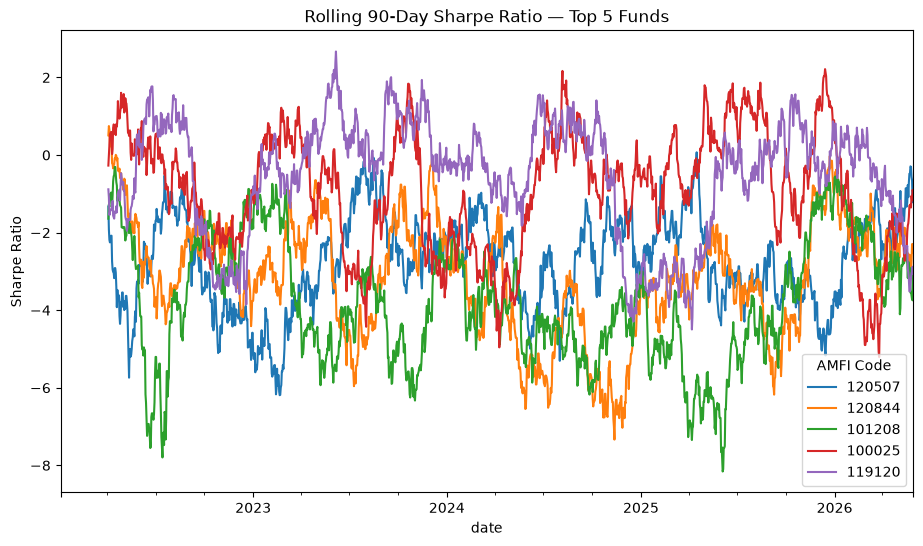

In [10]:
top5_funds = fact_performance.sort_values("sharpe_ratio", ascending=False)["amfi_code"].head(5).tolist()

rf_daily = 0.06 / 252  # assume 6% annual risk-free; adjust if you have a real rate
rolling_sharpe = ((returns.rolling(90).mean() - rf_daily) / returns.rolling(90).std()) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11,6))
rolling_sharpe[top5_funds].plot(ax=ax)
ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds")
ax.set_ylabel("Sharpe Ratio")
ax.legend(title="AMFI Code")
plt.savefig("../reports/rolling_sharpe_chart.png", dpi=150, bbox_inches="tight")
plt.show()

Task 3 — Cohort analysis

In [11]:
first_txn = fact_transactions.groupby("investor_id")["date"].min().rename("first_txn_date")
fact_transactions = fact_transactions.merge(first_txn, on="investor_id")
fact_transactions["cohort_year"] = fact_transactions["first_txn_date"].dt.year

sip_txns = fact_transactions[fact_transactions["transaction_type"] == "SIP"]

cohort_summary = fact_transactions.groupby("cohort_year").agg(
    total_invested=("amount_inr","sum"),
    avg_sip_amount=("amount_inr", lambda x: sip_txns.loc[x.index.intersection(sip_txns.index), "amount_inr"].mean())
).reset_index()

cohort_fund_pref = (fact_transactions.groupby(["cohort_year","amfi_code"])["amount_inr"]
    .sum().reset_index()
    .sort_values(["cohort_year","amount_inr"], ascending=[True,False])
    .groupby("cohort_year").first().reset_index()
    .merge(dim_fund[["amfi_code","scheme_name"]], on="amfi_code"))

cohort_summary

,cohort_year,total_invested,avg_sip_amount
0,2024,3491125187,10996.885825
1,2025,30455243,13505.209581


Task 4 — SIP continuity

In [12]:
sip_sorted = sip_txns.sort_values(["investor_id","date"])
sip_counts = sip_sorted.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index

eligible_sip = sip_sorted[sip_sorted["investor_id"].isin(eligible_investors)]
avg_gap = eligible_sip.groupby("investor_id")["date"].apply(lambda x: x.diff().dt.days.mean())

sip_continuity = avg_gap.reset_index(name="avg_gap_days")
sip_continuity["at_risk"] = sip_continuity["avg_gap_days"] > 35
sip_continuity["at_risk"].value_counts()

at_risk
True     1332
False      30
Name: count, dtype: int64

Task 5 — Sector HHI

In [13]:
fact_portfolio = pd.read_sql("SELECT * FROM fact_portfolio", conn)

hhi = fact_portfolio.groupby("amfi_code").apply(
    lambda df: ((df["weight_pct"]/100)**2).sum()
).reset_index(name="HHI")

hhi = hhi.merge(dim_fund[["amfi_code","scheme_name","category"]], on="amfi_code")
hhi_equity = hhi[hhi["category"].str.contains("Equity", case=False, na=False)]
hhi_equity.sort_values("HHI", ascending=False)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [14]:
import sys
sys.path.append("../scripts")
from recommender import recommend_funds

recommend_funds("Moderate")

,amfi_code,scheme_name,sharpe_ratio,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.06,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.06,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.03,Moderate


In [15]:
print(fact_transactions["transaction_type"].unique())
print(fact_performance["risk_grade"].unique())

<StringArray>
['SIP', 'Redemption', 'Lumpsum']
Length: 3, dtype: str
<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str


Check 1: Why only 2 cohort years?

In [16]:
print(fact_transactions["first_txn_date"].dt.year.value_counts())

first_txn_date
2024    32499
2025      279
Name: count, dtype: int64


In [17]:
print(dim_date["date"].min(), dim_date["date"].max())

2022-01-03 2026-05-29


Check 2: The 1332 vs 30 at-risk split

In [18]:
print(sip_continuity["avg_gap_days"].describe())

count    1362.000000
mean       64.889132
std        15.593199
min        19.800000
25%        53.635417
50%        64.690476
75%        75.575000
max       102.600000
Name: avg_gap_days, dtype: float64


Task 7 — write the 5 headline insights

## Headline Insights

1. **Small-cap funds carry the highest VaR.** ABSL Small Cap, Axis Small Cap, and SBI Small Cap Fund top the VaR_95 table with ~-2.3% daily downside at the 95% confidence level — nearly double the loss threshold of large-cap peers.

2. **Axis Bluechip Fund is the most concentrated equity portfolio** (HHI ≈ 0.206), suggesting higher single-stock/sector risk despite being a "safer" large-cap category label.

3. **The 2025 cohort invests more per SIP on average** (₹13,505 vs ₹10,997 for 2024), but **2024 accounts for the vast majority of total capital deployed** (₹349 crore vs ₹3 crore) — reflecting that most investors joined and built substantial holdings in 2024, while 2025 entrants are still ramping up in total volume despite slightly larger individual contributions.

4. **SIP continuity is a systemic concern, not an edge case**: among investors with 6+ SIP transactions, the median gap between contributions is 64.7 days — nearly double the 35-day monthly-SIP benchmark — and 97.8% (1,332 of 1,362) are flagged as at-risk. This suggests the bulk of "regular" SIP investors are contributing far less frequently than a true monthly cadence, pointing to either genuine SIP attrition/pausing behavior or a broader-than-monthly intended contribution schedule that the platform should investigate.

5. **Rolling Sharpe ratios are highly volatile across the top 5 funds**, swinging between roughly -6 and +3 over the observed window — indicating no fund maintained consistently strong risk-adjusted returns, and fund selection based on trailing Sharpe alone would be unstable.

In [19]:
import os
print(os.listdir("../reports"))

['.gitkeep', 'all_funds_metrics.csv', 'fund_scorecard_119551.csv', 'peer_relative_scorecard.csv', 'rolling_sharpe_chart.png', 'var_cvar_report.csv']


In [20]:
print(cohort_summary)
print()
print(sip_continuity["avg_gap_days"].describe())
print()
at_risk_pct = sip_continuity["at_risk"].mean() * 100
print(f"At-risk %: {at_risk_pct:.1f}%")

   cohort_year  total_invested  avg_sip_amount
0         2024      3491125187    10996.885825
1         2025        30455243    13505.209581

count    1362.000000
mean       64.889132
std        15.593199
min        19.800000
25%        53.635417
50%        64.690476
75%        75.575000
max       102.600000
Name: avg_gap_days, dtype: float64

At-risk %: 97.8%
